In [6]:
import os
import sys
import numpy as np
import pandas as pd
import jax.numpy as jp
import scipy.sparse
import gast_model as gm

from paths import Paths
from simulation_utils import run_bold_sweep

# ------------------------
# Parse args
# ------------------------

subject_id   = 'sub-HC01'          # sub-XXXX
we           = 0.1
sigma   = 0.1
Ja   = 10
v_c = 3.9
dt = 0.1

DERIV_DIR = os.path.join(Paths.DERIVATIVES, subject_id)

# ------------------------
# Load subject-specific data
# ------------------------

L = np.loadtxt(os.path.join(DERIV_DIR, "dwi/dk_lengths.txt"))
C = np.loadtxt(os.path.join(DERIV_DIR, "dwi/dk_weights.txt"))
C = C /np.max(C)
idelays = (L[C != 0.0] / v_c / dt).astype(np.uint32)

In [2]:
C.shape

(84, 84)

In [10]:
# ------------------------
# Model setup
# ------------------------

setup = {
    "Seids": scipy.sparse.csr_matrix(C),
    "idelays": idelays,
    "params": gm.default_theta,
    "v_c": v_c,
    "horizon": 650,
    "num_item": 1,
    "dt": dt,
    "num_skip": 10,
    "num_time": 300000,
    "init_state": jp.array([.01, -55.0, 0.0, 0.0]).reshape(4,1),
    "num_svar": 4,
    "noise": sigma,
}

# ------------------------
# Parameter update
# ------------------------

theta = gm.default_theta._replace(
    we=we,
    J=Ja,
    sigma_V=setup["noise"],
    sigma_u=0.1 * setup["noise"],
)

setup["params"] = theta

# ------------------------
# Run simulation
# ------------------------

bold = run_bold_sweep((theta, setup))

bold = np.asarray(bold)

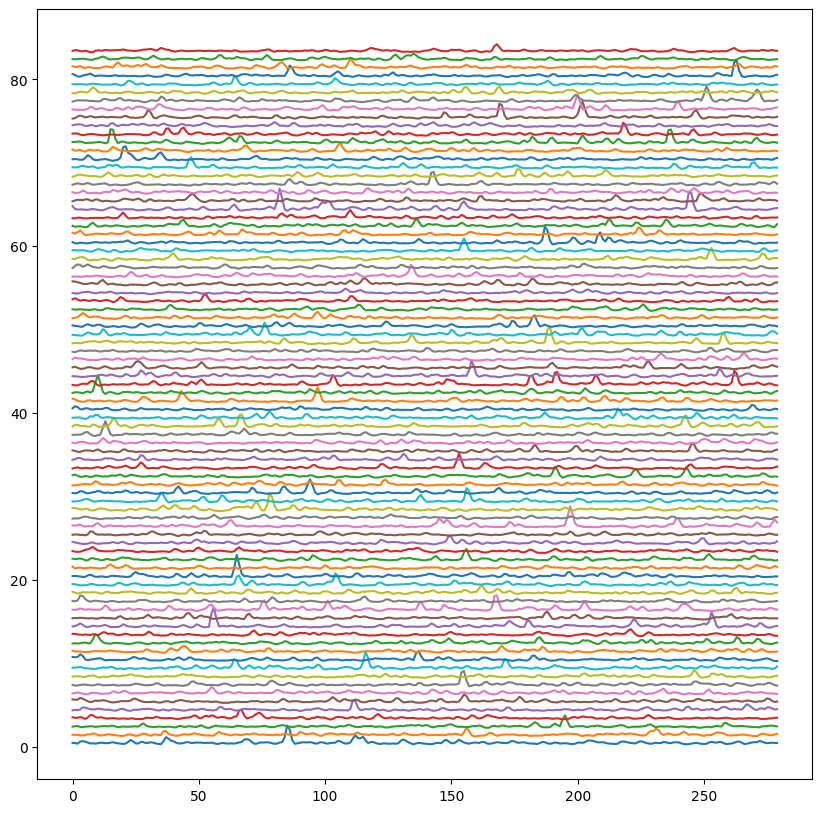

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.plot(np.arange(bold.shape[1]) + 3*bold[:,:,0]/bold[:,:,0].max());